# 第 8 章 · TransE 与 Attention 代码实验

[章节网页](../ch8.html)

## 运行内容

- 计算 TransE 距离
- 计算 attention 权重
- 绘制几何图和热力图

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

## 1. TransE

In [2]:
# TransE：比较正确三元组和替换实体后的距离。
entity_vec = {
    "鲁迅": np.array([0.10, 0.82]),
    "《呐喊》": np.array([0.72, 0.60]),
    "《边城》": np.array([0.20, 0.15]),
    "沈从文": np.array([0.08, 0.20]),
}
relation_vec = {"创作": np.array([0.60, -0.18])}

triples = [
    ("鲁迅", "创作", "《呐喊》", "正例"),
    ("鲁迅", "创作", "《边城》", "替换尾实体"),
    ("沈从文", "创作", "《呐喊》", "替换头实体"),
]

rows = []
for head, relation, tail, kind in triples:
    score_vec = entity_vec[head] + relation_vec[relation] - entity_vec[tail]
    rows.append({
        "样本": kind,
        "三元组": f"({head}, {relation}, {tail})",
        "距离": round(float(np.linalg.norm(score_vec)), 3),
    })

transe_df = pd.DataFrame(rows).sort_values("距离")
display(transe_df)

,样本,三元组,距离
0,正例,"(鲁迅, 创作, 《呐喊》)",0.045
2,替换头实体,"(沈从文, 创作, 《呐喊》)",0.581
1,替换尾实体,"(鲁迅, 创作, 《边城》)",0.700


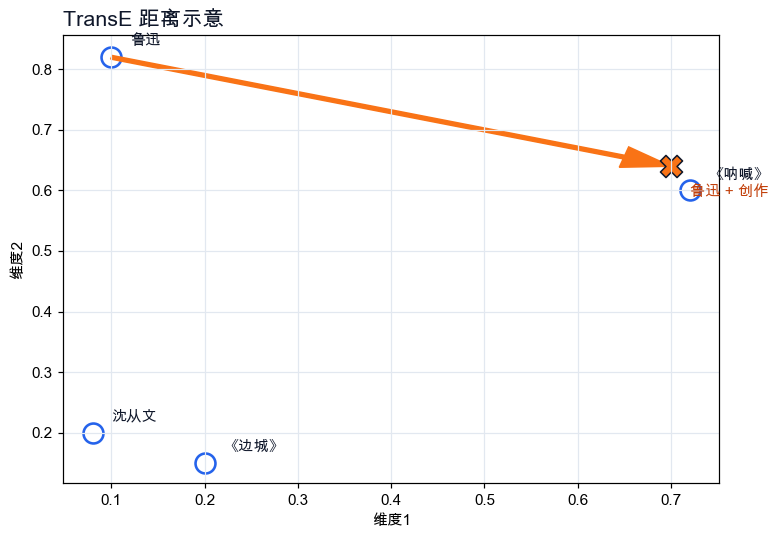

In [3]:
# 绘制 h + r 与候选 t 的几何距离。
fig, ax = plt.subplots(figsize=(7.2, 5.0))
h = entity_vec["鲁迅"]
r = relation_vec["创作"]
target_point = h + r

for name, vec in entity_vec.items():
    ax.scatter(vec[0], vec[1], s=170, color="#ffffff", edgecolor="#2563eb", linewidth=1.7)
    ax.text(vec[0] + 0.02, vec[1] + 0.02, name, color="#0f172a")

ax.arrow(h[0], h[1], r[0], r[1], width=0.006, head_width=0.035, color="#f97316", length_includes_head=True)
ax.scatter(target_point[0], target_point[1], s=210, marker="X", color="#f97316", edgecolor="#0f172a", linewidth=1.0)
ax.text(target_point[0] + 0.02, target_point[1] - 0.05, "鲁迅 + 创作", color="#c2410c")
ax.set_title("TransE 距离示意", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax.set_xlabel("维度1")
ax.set_ylabel("维度2")
ax.grid(True, color="#e2e8f0", linewidth=0.8)
plt.tight_layout()
plt.show()

## 2. Attention

In [4]:
# Scaled dot-product attention：计算分数、权重和加权输出。
tokens = ["我", "喜欢", "学习", "AI"]
X_attn = np.array([
    [0.8, 0.1, 0.0],
    [0.7, 0.2, 0.2],
    [0.1, 0.8, 0.3],
    [0.2, 0.4, 0.9],
])
Wq = np.array([[0.7, 0.1], [0.2, 0.8], [0.1, 0.3]])
Wk = np.array([[0.6, 0.2], [0.3, 0.7], [0.2, 0.4]])
Wv = np.array([[0.5, 0.1], [0.2, 0.7], [0.3, 0.5]])

Q = X_attn @ Wq
K = X_attn @ Wk
V = X_attn @ Wv
scores = Q @ K.T / math.sqrt(K.shape[1])
weights = np.exp(scores - scores.max(axis=1, keepdims=True))
weights = weights / weights.sum(axis=1, keepdims=True)
attn_output = weights @ V

display(pd.DataFrame(np.round(weights, 3), index=tokens, columns=tokens))
display(pd.DataFrame(np.round(attn_output, 3), index=tokens, columns=["输出1", "输出2"]))

,我,喜欢,学习,AI
我,0.248,0.253,0.246,0.252
喜欢,0.242,0.250,0.252,0.256
学习,0.219,0.235,0.273,0.273
AI,0.225,0.239,0.267,0.268


,输出1,输出2
我,0.406,0.482
喜欢,0.405,0.487
学习,0.403,0.507
AI,0.403,0.502


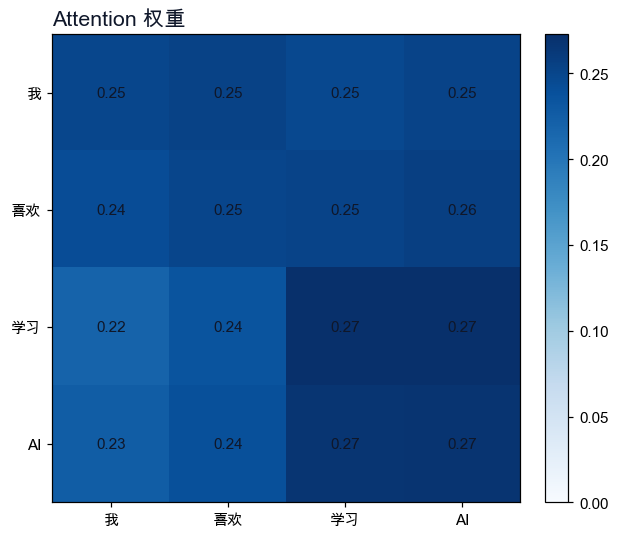

In [5]:
# 绘制 attention 权重热力图。
fig, ax = plt.subplots(figsize=(6.2, 5.0))
im = ax.imshow(weights, cmap="Blues", vmin=0, vmax=weights.max())
ax.set_xticks(range(len(tokens)), tokens)
ax.set_yticks(range(len(tokens)), tokens)
for i in range(len(tokens)):
    for j in range(len(tokens)):
        ax.text(j, i, f"{weights[i, j]:.2f}", ha="center", va="center", color="#0f172a")
ax.set_title("Attention 权重", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()